# Cross-motif structural reuse — Extension B

**Phase 3 deliverable, prof-recommended.** Question: across training, does the same physical (layer, head) appear in the top-K of multiple motifs, or are the three motif populations disjoint?

**Why this matters.** The H1-C compositional account predicts that S-inhibition heads *consume* successor/induction outputs at later layers — i.e., they are structurally distinct heads. If we instead find substantial overlap between motif top-K populations (e.g., a head that scores high on both successor and S-inhibition), that would suggest *circuit reuse* rather than compositional layering.

**Method.** For each (size, step), rank heads by motif score and take top-K (K=5). Compute pairwise Jaccard similarity across motif top-K sets. Plot Jaccard over training. Surface any heads that appear in ≥ 2 motifs' top-K at any step (the candidate multi-motif heads).

**Caveat.** Top-K membership uses score rank, not threshold-pass. A head can be in successor's top-K with a low absolute score (if the motif fails to emerge in that cell). The threshold-pass version is in the per-motif `_full_sweep` notebooks; this one uses rank-based overlap to track *relative* identity churn.

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long

SIZES = ['70m', '160m', '410m', '1b']
MOTIFS = ['induction', 'successor', 's_inhibition']
MOTIF_LABEL = {'induction': 'induction', 'successor': 'successor', 's_inhibition': 'S-inhibition'}
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green', '1b': 'tab:red'}
PAIR_COLOR = {
    ('induction', 'successor'): 'tab:purple',
    ('induction', 's_inhibition'): 'tab:olive',
    ('successor', 's_inhibition'): 'tab:cyan',
}
K_TOP = 5

## Load all sweep parquets (3 Phase 2 sizes + 1 Phase 3 1B)

In [2]:
# Phase 2 (3 sizes) and Phase 3 (1B) parquets are concatenated for the
# 4-size structural-reuse extension per §H3-scale-8 (#6).
df_ind = pd.concat([
    read_long(REPO / 'data' / 'exploration' / 'phase2_induction_sweep.parquet'),
    read_long(REPO / 'data' / 'exploration' / 'phase3_1b_induction_sweep.parquet'),
])
df_suc = pd.concat([
    read_long(REPO / 'data' / 'exploration' / 'phase2_successor_sweep.parquet'),
    read_long(REPO / 'data' / 'exploration' / 'phase3_1b_successor_sweep.parquet'),
])
df_si = pd.concat([
    read_long(REPO / 'data' / 'exploration' / 'phase2_s_inhibition_sweep.parquet'),
    read_long(REPO / 'data' / 'exploration' / 'phase3_1b_s_inhibition_sweep.parquet'),
])
DFS = {'induction': df_ind, 'successor': df_suc, 's_inhibition': df_si}
STEPS = sorted(df_ind.step.unique().tolist())
print(f'Loaded sweeps: {len(STEPS)} cells per size, {len(SIZES)} sizes, {len(MOTIFS)} motifs.')

Loaded sweeps: 40 cells per size, 4 sizes, 3 motifs.


## Top-K head sets per (size, step, motif)

For each cell, take the K=5 highest-scoring (layer, head) pairs per motif. The set of these pairs is the motif's "top-K identity" at that cell. We then ask: do these sets overlap across motifs?

In [3]:
topk = {}  # {(size, step, motif): set of (layer, head) tuples}
for motif, df in DFS.items():
    for size in SIZES:
        for step in STEPS:
            sub = df[(df['size'] == size) & (df['step'] == step)]
            if sub.empty:
                topk[(size, step, motif)] = set()
                continue
            top = sub.nlargest(K_TOP, 'score')[['layer', 'head']]
            topk[(size, step, motif)] = set(map(tuple, top.values.tolist()))
print(f'Built top-{K_TOP} sets for {len(topk):,} (size, step, motif) cells.')

Built top-5 sets for 480 (size, step, motif) cells.


## Pairwise Jaccard overlap across motifs over training

Jaccard(A, B) = |A ∩ B| / |A ∪ B|. For top-K sets of the same size K, this ranges 0 (no overlap) to 1 (identical heads). Three pair-curves per panel: (induction, successor), (induction, S-inhibition), (successor, S-inhibition).

In [4]:
PAIRS = [
    ('induction', 'successor'),
    ('induction', 's_inhibition'),
    ('successor', 's_inhibition'),
]
rows = []
for size in SIZES:
    for step in STEPS:
        for ma, mb in PAIRS:
            sa = topk[(size, step, ma)]
            sb = topk[(size, step, mb)]
            union = sa | sb
            jac = (len(sa & sb) / len(union)) if union else 0.0
            rows.append(dict(
                size=size, step=step,
                pair=f'{ma}↔{mb}',
                jaccard=jac,
                intersection_size=len(sa & sb),
            ))
jac_df = pd.DataFrame(rows)

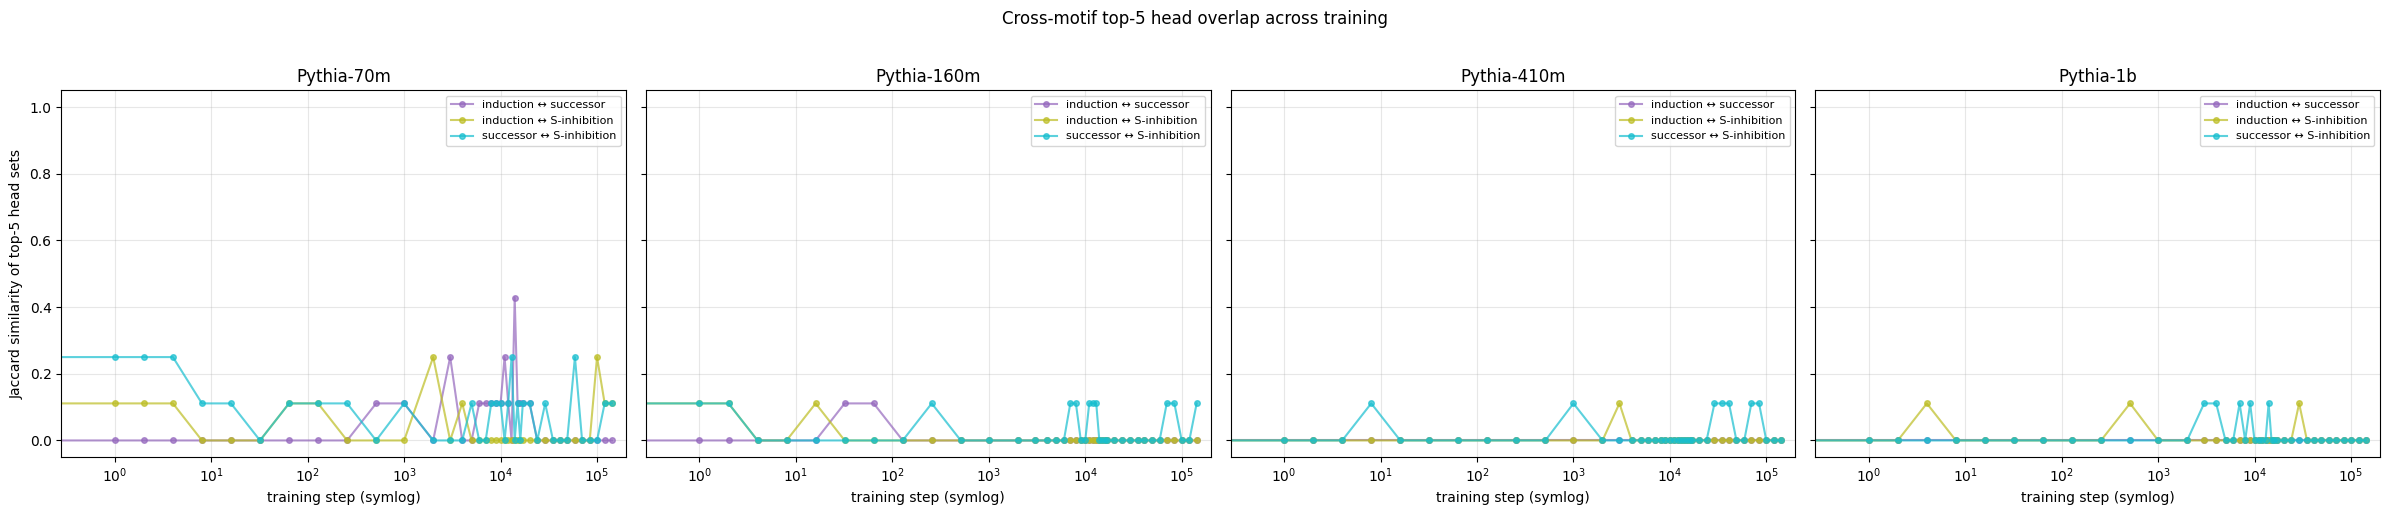

In [5]:
fig, axes = plt.subplots(1, len(SIZES), figsize=(6 * len(SIZES), 5), sharey=True)
for ax, size in zip(axes, SIZES):
    sub = jac_df[jac_df['size'] == size]
    for (ma, mb) in PAIRS:
        line = sub[sub['pair'] == f'{ma}↔{mb}'].sort_values('step')
        ax.plot(line['step'], line['jaccard'],
                marker='o', alpha=0.7, markersize=4,
                color=PAIR_COLOR[(ma, mb)],
                label=f'{MOTIF_LABEL[ma]} ↔ {MOTIF_LABEL[mb]}')
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(0.5, 200000)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('training step (symlog)')
    if size == SIZES[0]:
        ax.set_ylabel(f'Jaccard similarity of top-{K_TOP} head sets')
    ax.set_title(f'Pythia-{size}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle(f'Cross-motif top-{K_TOP} head overlap across training', y=1.02)
plt.tight_layout()
plt.show()

**Reading the plot.** A Jaccard ≈ 0 line indicates the two motifs are implemented by structurally disjoint head populations — the compositional account's prediction. A Jaccard ≈ 1/K (with K=5, that's 0.2) indicates ~ 1 head consistently shared. Higher Jaccard indicates substantial circuit reuse.

Interpret carefully near the early-training pre-emergence regime: before motif emergence, top-K is whatever heads happen to score highest on noise. Post-emergence (after each motif's μ), the overlap reading is meaningful.

## Multi-motif heads — single-head appearances in top-K of ≥ 2 motifs

List every (size, layer, head) that appears in the top-K of at least 2 motifs at the final checkpoint (step143000). These are the candidate multi-purpose heads.

In [6]:
rows = []
for size in SIZES:
    head_motif_count = {}  # (layer, head) -> set of motifs
    for motif in MOTIFS:
        for lh in topk[(size, 143000, motif)]:
            head_motif_count.setdefault(lh, set()).add(motif)
    multi = {lh: ms for lh, ms in head_motif_count.items() if len(ms) >= 2}
    if not multi:
        rows.append(dict(size=size, layer=None, head=None,
                         motifs='(none)',
                         note='no multi-motif heads at step143000'))
        continue
    for (layer, head), motifs in sorted(multi.items()):
        rows.append(dict(
            size=size, layer=int(layer), head=int(head),
            motifs=' + '.join(sorted(motifs)),
            note='',
        ))
multi_df = pd.DataFrame(rows)
print('Multi-motif heads at step143000 (top-K of ≥ 2 motifs simultaneously):')
print(multi_df.to_string(index=False))

Multi-motif heads at step143000 (top-K of ≥ 2 motifs simultaneously):


size  layer  head                   motifs                               note
 70m    3.0   5.0 induction + s_inhibition                                   
 70m    4.0   0.0 s_inhibition + successor                                   
160m    8.0   9.0 s_inhibition + successor                                   
410m    NaN   NaN                   (none) no multi-motif heads at step143000
  1b    NaN   NaN                   (none) no multi-motif heads at step143000


## Persistence: multi-motif heads across training

If a head fires in multiple motifs at the final checkpoint but only in one motif during early training, the multi-motif behavior is a developmental phenomenon, not a stable property. Conversely, if a head fires in multiple motifs across most checkpoints, the multi-motif role is structural.

Per (size, layer, head) seen in multi_df above, plot the score trajectory across training in each motif it participates in.

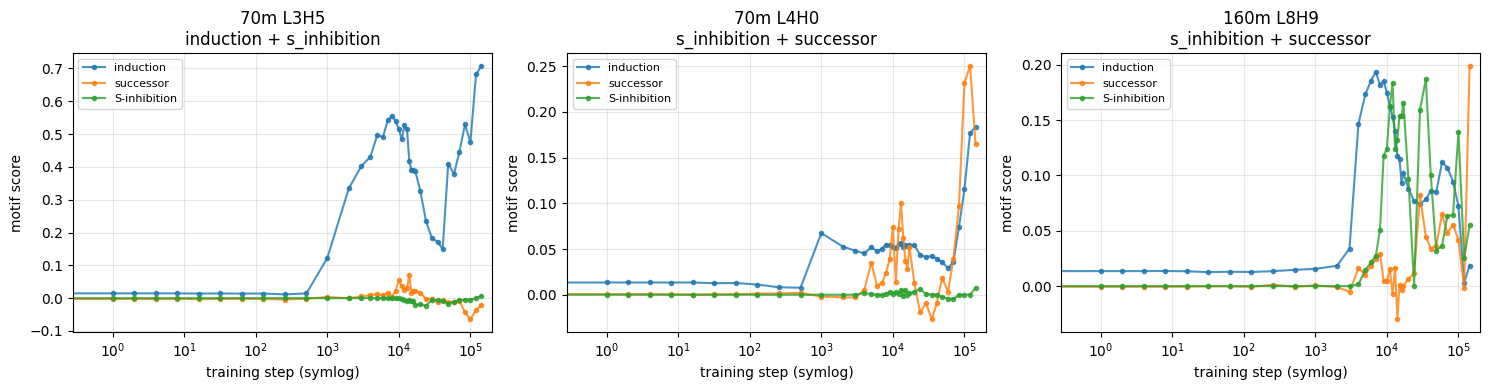

In [7]:
if multi_df['layer'].notna().any():
    rows_for_plot = multi_df[multi_df['layer'].notna()].copy()
    n_panels = len(rows_for_plot)
    if n_panels > 0:
        fig, axes = plt.subplots(
            1, n_panels,
            figsize=(5 * n_panels, 4),
            squeeze=False,
        )
        for col, (_, row) in enumerate(rows_for_plot.iterrows()):
            ax = axes[0, col]
            size, layer, head, motifs_str = row['size'], int(row['layer']), int(row['head']), row['motifs']
            for motif in MOTIFS:
                df = DFS[motif]
                trace = df[(df['size'] == size) & (df['layer'] == layer) & (df['head'] == head)].sort_values('step')
                if trace.empty:
                    continue
                ax.plot(trace['step'], trace['score'], marker='o', markersize=3,
                        label=MOTIF_LABEL[motif], alpha=0.8)
            ax.set_xscale('symlog', linthresh=1)
            ax.set_xlim(0.5, 200000)
            ax.set_xlabel('training step (symlog)')
            ax.set_ylabel('motif score')
            ax.set_title(f'{size} L{layer}H{head}\n{motifs_str}')
            ax.grid(alpha=0.3)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
    else:
        print('No multi-motif heads to plot.')
else:
    print('No multi-motif heads identified at step143000 in any size.')

## Verdict — what does structural reuse tell us about H1-C?

Three readings, depending on what the Jaccard plot and multi-motif table show:

**Reading A — disjoint populations (Jaccard ≈ 0 post-emergence; multi_df empty).** Each motif lives in its own head population. This is consistent with the compositional account in the registered hypothesis (different motifs implement different functions; corrective heads at later layers consume copying-head outputs at earlier layers). The depth-vs-temporal asymmetry observed in `h1c_ordering_test.ipynb` sub-deliverable 4b becomes more puzzling — disjoint populations *and* depth-reversal points away from the simple compositional reading.

**Reading B — sustained overlap (Jaccard > 0.2 post-emergence; multi_df populated).** Some heads persistently fire in multiple motifs. This argues *against* the compositional reading and *for* a circuit-reuse account where individual heads serve multiple functions. The H1-C temporal ordering would then be a property of when heads' multiple roles pass detection thresholds, not a property of distinct circuit components emerging in sequence.

**Reading C — late-training drift to overlap.** Jaccard rises during training. This suggests that as training progresses, heads broaden their role from specialist to multi-purpose. The temporal ordering hypothesis would still be coherent (heads first specialize, then broaden), but the late-checkpoint multi-motif behavior would caution against treating step143000 as a clean snapshot of a compositional circuit.

**For the BlackboxNLP writeup.** Whichever reading the data supports, it sharpens the H1-C interpretation. Reading A reinforces the registered architecture story but deepens the depth-asymmetry puzzle. Reading B reframes the result more aggressively. Reading C suggests caution about static late-checkpoint inspection.